# Preparing data

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
raw_data = pd.read_csv('summary_results.csv', sep=',', decimal='.', index_col=0)
raw_data

,instance,status,obj,model time (s),total time (s),gap
0,BAG_10_p2_1_makespan,2,6346.0,7.532,7.581348,0.000000
0,BAG_10_p2_1_deadline,2,5266.0,3.006,3.054831,0.000000
0,BAG_10_p2_2_makespan,2,6071.0,2.436,2.485911,0.000000
0,BAG_10_p2_2_deadline,2,4991.0,3.048,3.097810,0.000000
0,BAG_10_p2_3_makespan,2,6160.0,3.976,4.027241,0.000000
...,...,...,...,...,...,...
0,GNR_20_p3_3_makespan,9,9139.0,3600.513,3613.654551,0.411314
0,GNR_20_p3_3_deadline,9,6886.0,3600.424,3602.749533,0.578856
0,GNR_20_p3_4_makespan,9,8986.0,3600.527,3602.695878,0.448030
0,GNR_20_p3_4_deadline,9,5491.0,3600.585,3602.745771,0.533054


In [87]:
new_cols = pd.DataFrame({'type': row[0], 'L': row[1], 'p': row[2], 'n': row[3], 'obj_name': row[4] } for row in raw_data['instance'].str.split('_'))
new_cols

,type,L,p,n,obj_name
0,BAG,10,p2,1,makespan
1,BAG,10,p2,1,deadline
2,BAG,10,p2,2,makespan
3,BAG,10,p2,2,deadline
4,BAG,10,p2,3,makespan
...,...,...,...,...,...
294,GNR,20,p3,3,makespan
295,GNR,20,p3,3,deadline
296,GNR,20,p3,4,makespan
297,GNR,20,p3,4,deadline


In [88]:
df_complete = pd.concat([raw_data.reset_index(drop=True), new_cols.reset_index(drop=True)], axis='columns')
df = df_complete[['obj_name', 'type', 'L', 'p', 'n', 'obj', 'gap', 'model time (s)']]
df = df.rename(columns={'obj_name': 'obj_name', 'type': 'g_type', 'L': 'l', 'p': 'p', 'n': 'n', 'obj': 'obj_value', 'model time (s)': 'total_seconds'})
df

,obj_name,g_type,l,p,n,obj_value,gap,total_seconds
0,makespan,BAG,10,p2,1,6346.0,0.000000,7.532
1,deadline,BAG,10,p2,1,5266.0,0.000000,3.006
2,makespan,BAG,10,p2,2,6071.0,0.000000,2.436
3,deadline,BAG,10,p2,2,4991.0,0.000000,3.048
4,makespan,BAG,10,p2,3,6160.0,0.000000,3.976
...,...,...,...,...,...,...,...,...
294,makespan,GNR,20,p3,3,9139.0,0.411314,3600.513
295,deadline,GNR,20,p3,3,6886.0,0.578856,3600.424
296,makespan,GNR,20,p3,4,8986.0,0.448030,3600.527
297,deadline,GNR,20,p3,4,5491.0,0.533054,3600.585


In [89]:
df.loc[df['total_seconds'] > 3600, 'total_seconds'] = 3600
df

,obj_name,g_type,l,p,n,obj_value,gap,total_seconds
0,makespan,BAG,10,p2,1,6346.0,0.000000,7.532
1,deadline,BAG,10,p2,1,5266.0,0.000000,3.006
2,makespan,BAG,10,p2,2,6071.0,0.000000,2.436
3,deadline,BAG,10,p2,2,4991.0,0.000000,3.048
4,makespan,BAG,10,p2,3,6160.0,0.000000,3.976
...,...,...,...,...,...,...,...,...
294,makespan,GNR,20,p3,3,9139.0,0.411314,3600.000
295,deadline,GNR,20,p3,3,6886.0,0.578856,3600.000
296,makespan,GNR,20,p3,4,8986.0,0.448030,3600.000
297,deadline,GNR,20,p3,4,5491.0,0.533054,3600.000


# Plotting

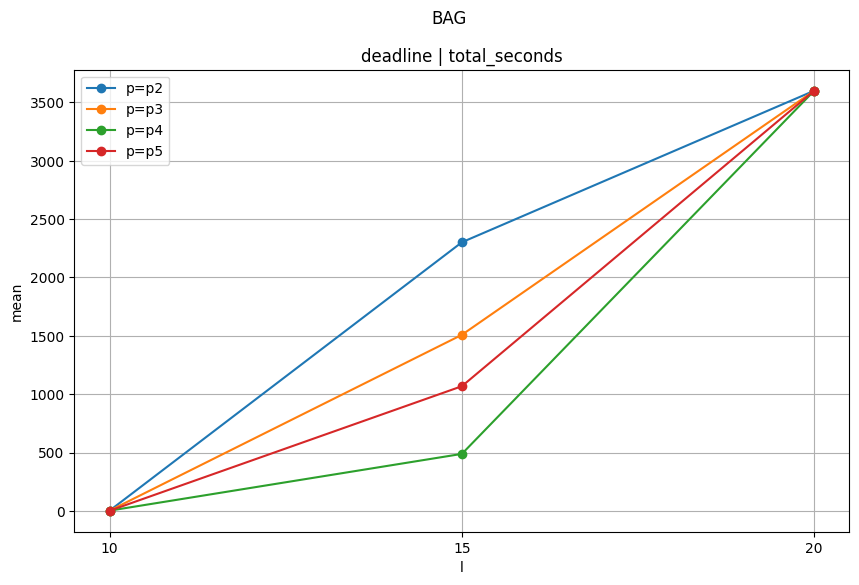

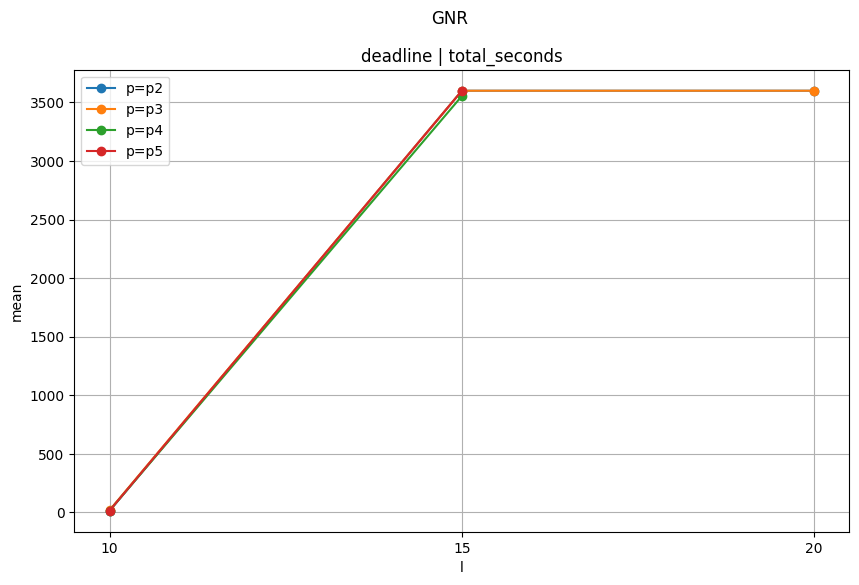

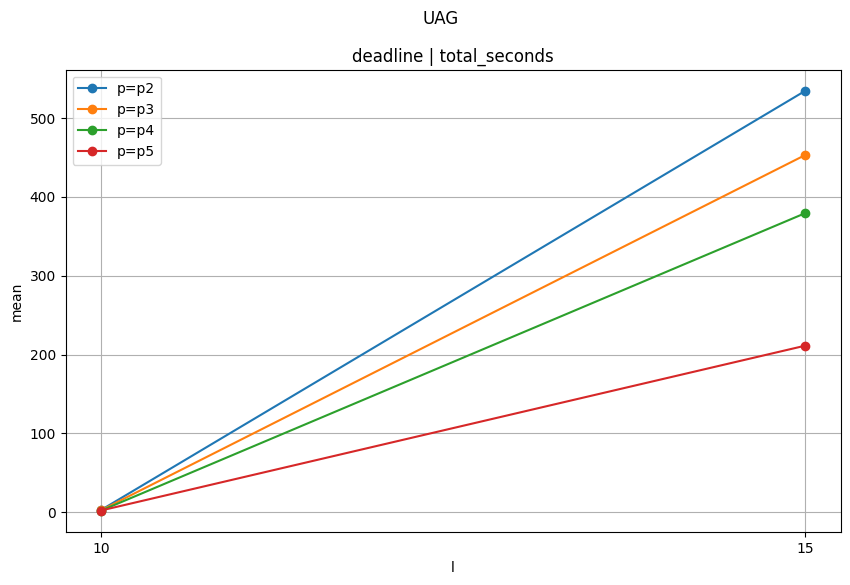

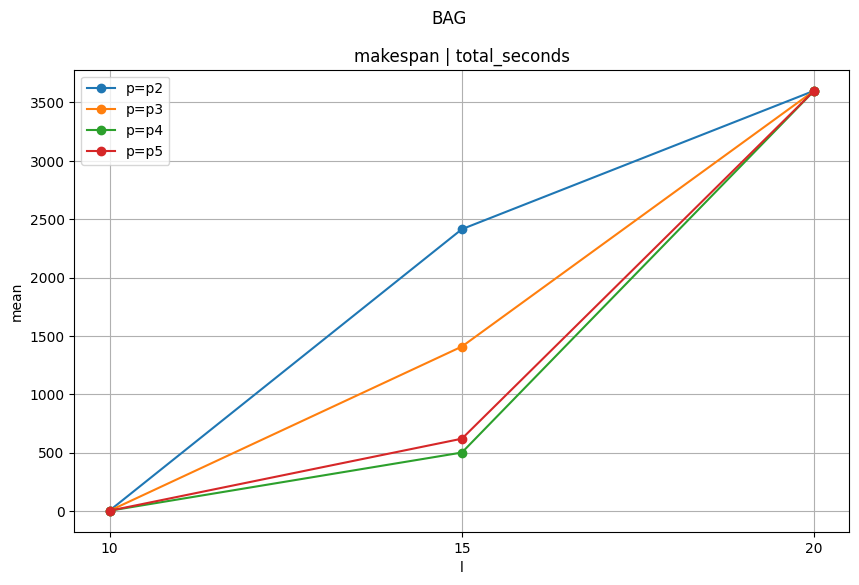

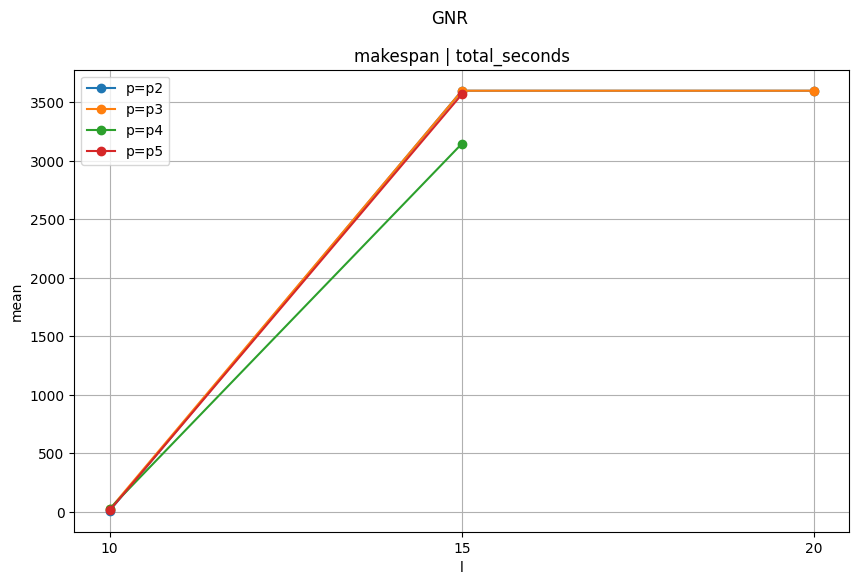

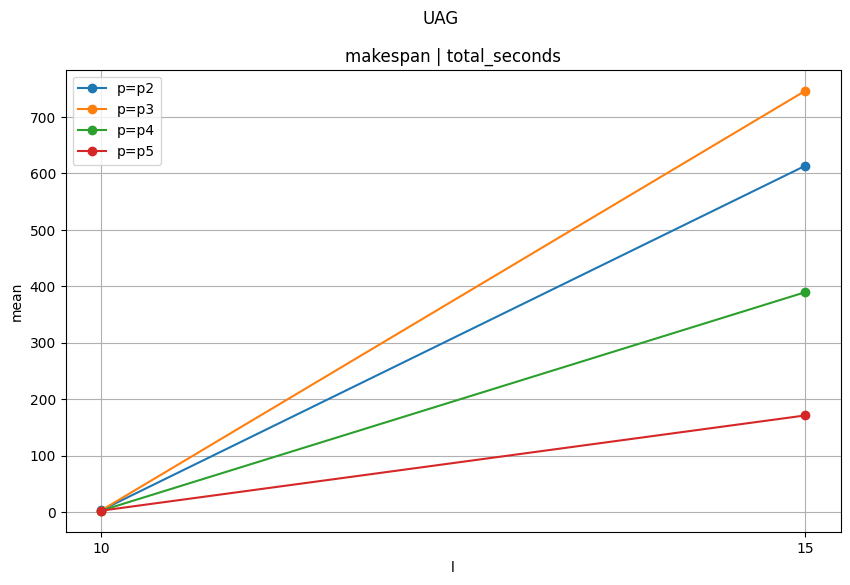

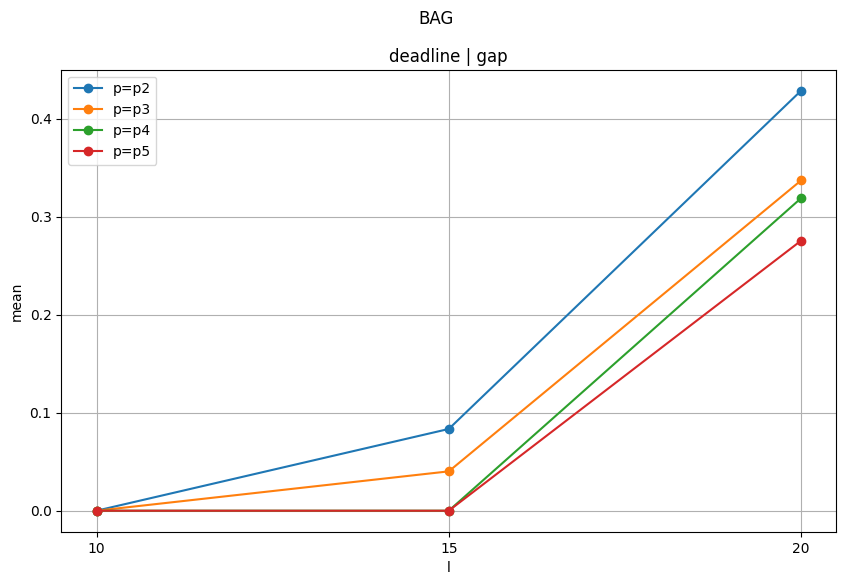

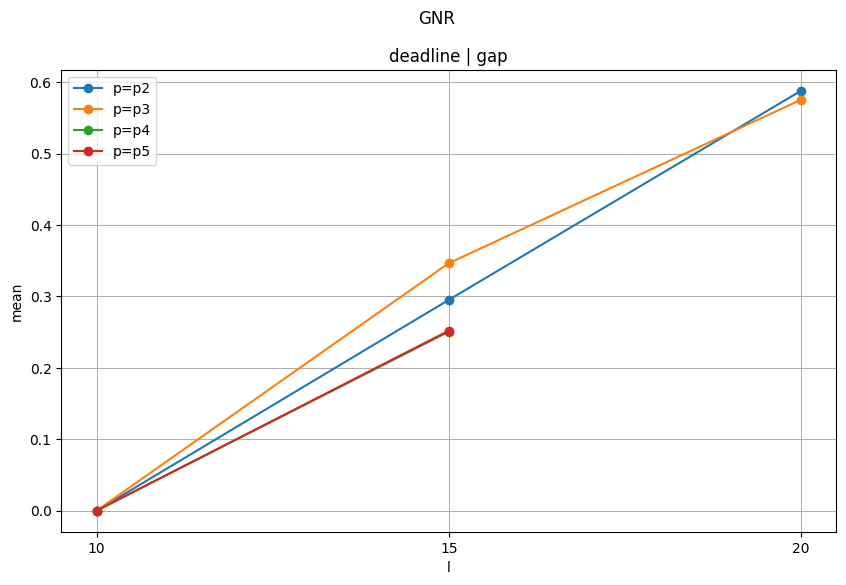

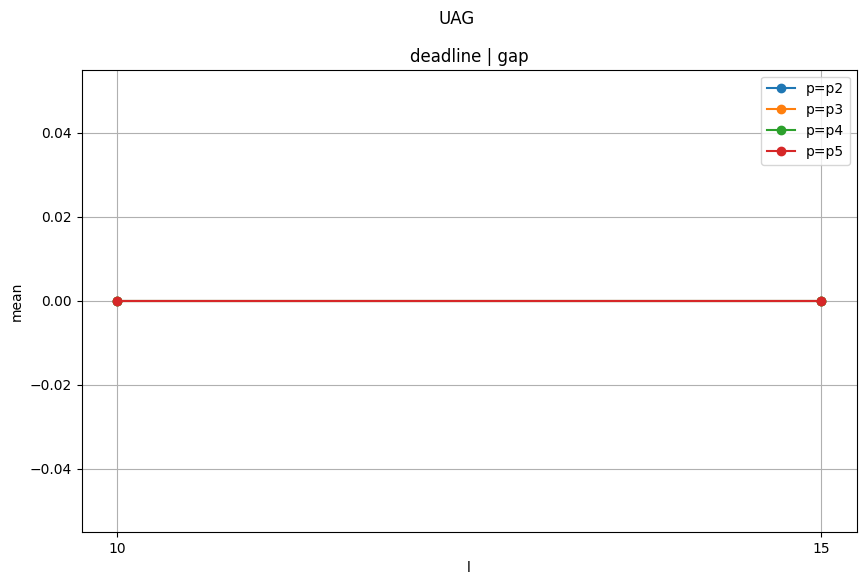

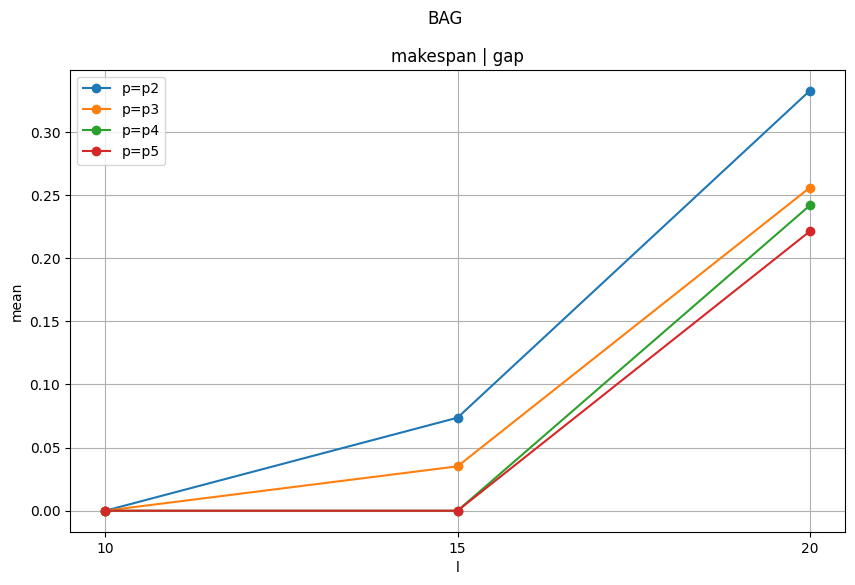

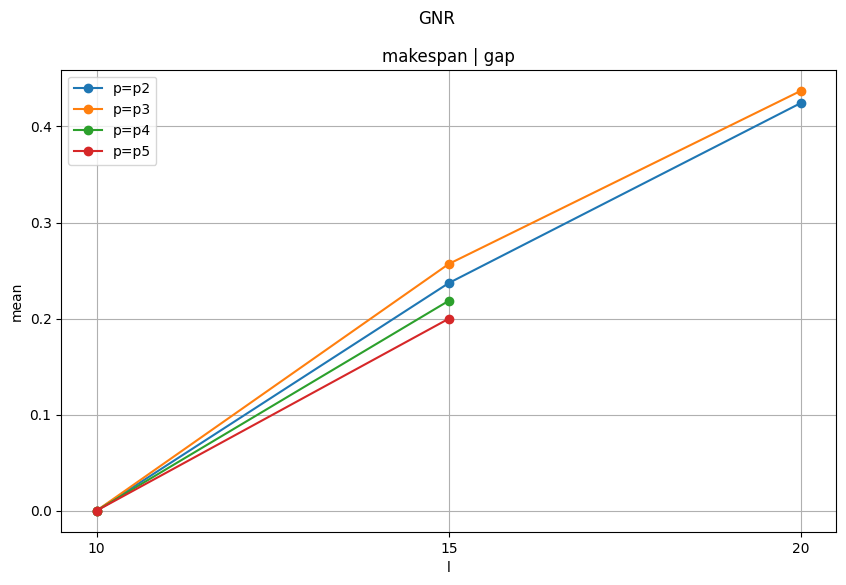

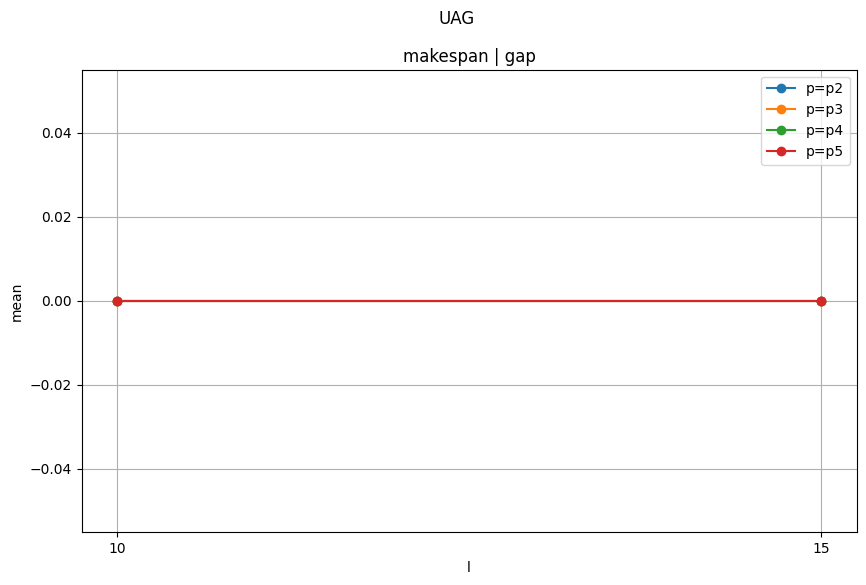

In [171]:
goals = ['total_seconds', 'gap']
resume = df.groupby(['obj_name', 'g_type', 'l', 'p', ])[goals].agg(['mean', 'std']).reset_index()
grouped = resume.groupby(['obj_name', 'g_type'])

for goal in goals:
    for (obj_name, g_type), group in grouped:
        plt.figure(figsize=(10, 6))
        for p_value in group['p'].unique():
            subset = group[group['p'] == p_value]
            plt.plot(subset['l'], subset.loc[:, (goal, 'mean')], marker='o', label=f'p={p_value}')
        
        # plt.title(f'Plot for {goal} obj_name={obj_name}, g_type={g_type}')
        
        plt.suptitle(f'{g_type}', fontsize=12)
        plt.title(f'{obj_name} | {goal}', fontsize=12)
        
        plt.xlabel('l')
        plt.ylabel('mean')
        plt.legend()
        plt.grid(True)
        # plt.ylim(top=3600)
        plt.show()

# Checking graph degrees

In [20]:
import os
import sys
import numpy as np

sys.path.insert(0, './../') 
from instance import Instance

In [21]:
instances_path = './../instances/'
print('Reading instances...')
all_instances = [Instance.from_json(instances_path, file.split('.')[0]) for file in os.listdir(instances_path)]
all_instances = sorted(all_instances, key=lambda x: x.l)

Reading instances...


In [23]:
for instance in all_instances:
    print('---------------')
    print(f'Instance: {instance.name}')
    for j in instance.U:
                        print(f'  -- Job: {j} | total degree: {np.sum([len(instance.U[j][l])*2 for l in instance.U[j]])}')

---------------
Instance: BAG_10_p2_1
  -- Job: 0 | total degree: 32
  -- Job: 1 | total degree: 32
  -- Job: 2 | total degree: 32
  -- Job: 3 | total degree: 32
  -- Job: 4 | total degree: 32
---------------
Instance: BAG_10_p2_2
  -- Job: 0 | total degree: 32
  -- Job: 1 | total degree: 32
  -- Job: 2 | total degree: 32
  -- Job: 3 | total degree: 32
  -- Job: 4 | total degree: 32
---------------
Instance: BAG_10_p2_3
  -- Job: 0 | total degree: 32
  -- Job: 1 | total degree: 32
  -- Job: 2 | total degree: 32
  -- Job: 3 | total degree: 32
  -- Job: 4 | total degree: 32
---------------
Instance: BAG_10_p2_4
  -- Job: 0 | total degree: 32
  -- Job: 1 | total degree: 32
  -- Job: 2 | total degree: 32
  -- Job: 3 | total degree: 32
  -- Job: 4 | total degree: 32
---------------
Instance: BAG_10_p2_5
  -- Job: 0 | total degree: 32
  -- Job: 1 | total degree: 32
  -- Job: 2 | total degree: 32
  -- Job: 3 | total degree: 32
  -- Job: 4 | total degree: 32
---------------
Instance: BAG_10_p3